<a id='home'></a>
### purpose

- set up the files that will be used to train gradientForests where the individuals of the same 'population' are not all assigned the same environmental values

- submit GF training jobs

### notes

- input files formatted here can be found in the tutorial from Lotterhos 2023 doi: 10.1073/pnas.2220313120
    - the original data can be found here:  https://marineomics.github.io/RDAtraitPredictionTutorial.html

### strategy
    - keep genotype data constant
    - vary training env data (whether pop-level or ind-level)
    - evaluate on same garden data (use same data as AF genetic data for 3-way comparison)
    
### outline
1. [assign individuals to populations](#assign)
1. [create marker sets](#create)
1. [create envdata for training](#envdata)
1. [figure out mem and run time using previous genotype data](#resources)
1. [create training shfiles](#train)
1. [get common garden data for predicting offset](#predict)
1. [create shfiles for offset prediction](#fitsh)

In [1]:
from pythonimports import *
import myfigs as mf

import MVP_03_validate_gradient_forests as mvp03
import MVP_06_validate_RONA as mvp06
import MVP_summary_functions as mvp
import runtime_API as rt

import seaborn as sns
import itertools as it

outerdir = makedir('/work/lotterhos/brandon/continuous_space_runtime')

# continuous space sims directory
tdir = '/home/b.lind/offsets/run_20220919_tutorial/tutorial'

# where to save GF files
training_dir = makedir(f'{outerdir}/gradient_forests/training/training_files')
outdir = makedir(f'{outerdir}/gradient_forests/training/training_outfiles')
shdir = makedir(f'{outerdir}/gradient_forests/training/training_shfiles')

fitting_dir = makedir(f'{outerdir}/gradient_forests/fitting')
fitting_outdir = makedir(f'{fitting_dir}/fitting_outfiles')
fitting_shdir = makedir(f'{fitting_dir}/fitting_shfiles')
garden_dir = makedir(f'{fitting_dir}/garden_files')
cmddir = makedir(f'{fitting_dir}/command_files')

t0 = dt.now()  # notebook timer

rt.latest_commit()
session_info.show()

#########################################################
Today:	December 03, 2024 - 17:05:19 EST
python version: 3.8.5
conda env: mvp_env

Current commit of pythonimports:
commit 6a767410e7b569adbf9df526de108f22ef50aad8  
Author: Brandon Lind <lind.brandon.m@gmail.com>  
Date:   Wed Mar 6 13:42:13 2024 -0700

Current commit of MVP_offsets:
commit 5ce82f4d655645237a0f4026fa32e220226dc373  
Author: Brandon Lind <lind.brandon.m@gmail.com>  
Date:   Thu May 16 13:02:58 2024 -0400

Current commit of MVP_runtime:
commit 1ad1ed65107af94c69eedbafcda212479d1cf351  
Author: Brandon Lind <lind.brandon.m@gmail.com>  
Date:   Mon Oct 7 10:12:18 2024 -0400
#########################################################



In [2]:
fitting_dir

'/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/fitting'

In [3]:
rt.resdir

'/work/lotterhos/brandon/runtime'

<a id='assign'></a>
# assign individuals to populations

this is only relevant to the pop-level envdata

[top](#home)

In [4]:
inds = pd.read_table(op.join(tdir, 'Individuals.txt'), delim_whitespace=True)

print(inds.shape)

inds.head()

(1000, 15)


,ind_index,x,y,phenotype1_mat,phenotype2_MTWetQ,phenotype3_MTDQ,phenotype4_PDM,phenotype5_PwarmQ,phenotype6_PWM,env1_mat,env2_MTWetQ,env3_MTDQ,env4_PDM,env5_PwarmQ,env6_PWM
0,33,0.406184,0.233272,0.737967,-0.191421,0.142992,-0.131894,-0.452497,-0.541651,0.762432,-0.162238,0.261281,-0.332078,-0.471502,-0.477821
1,34,0.425697,0.837158,-0.274081,-0.428332,-0.012880,0.221058,0.229296,0.066597,-0.339330,-0.407667,-0.058296,0.288030,0.198810,0.017680
2,44,0.671673,0.581744,-0.676326,0.086629,-0.470671,0.218813,0.260098,-0.103465,-0.567733,0.090928,-0.414353,0.234899,0.230255,-0.053511
3,45,0.017466,0.329922,-0.283221,-0.403942,-0.333718,-0.200554,-0.345915,-0.410001,-0.245860,-0.200759,-0.267455,-0.265260,-0.389828,-0.458979
4,46,0.069744,0.121221,0.057616,-0.303201,0.731600,0.195679,-0.367110,0.196296,-0.121500,-0.306379,0.702858,0.211275,-0.352307,0.212751


In [5]:
# are sample names unique? A: yes
assert len(inds.ind_index.unique()) == nrow(inds)

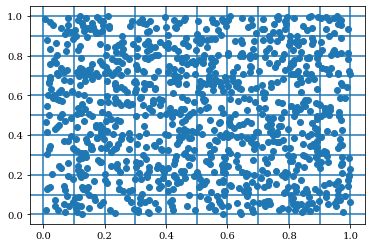

In [6]:
# how to assign pop ID
plt.scatter(inds.x, inds.y)
for x in range(0, 11, 1):
    
    plt.axhline(y = x / 10)
    plt.axvline(x = x / 10)

In [7]:
# assign indivudals to populations in the grid above

popsamps = {}

samppop = {}

samplocs = {}

samp_names = {}

pop = 1
y_start = 0
for y in range(1, 11, 1):
    y_end = y / 10
    
    x_start = 0
    for x in range(1, 11, 1):
        x_end = x / 10
        
        pop_inds = inds[(inds.y > y_start) & (inds.y <= y_end) &
                        (inds.x > x_start) & (inds.x <= x_end)
                       ]
        
        popsamps[pop] = [f'{pop}_{ind}' for ind in pop_inds.ind_index.to_list()]
        print(pop, nrow(pop_inds))
        
        for row, info in pop_inds.iterrows():
            samp = f'{pop}_%s' % int(info['ind_index'])
            samp_names[int(info['ind_index'])] = samp
            samplocs[samp] = tuple(pop_inds.loc[row, ['x', 'y']])
        
        for ind in pop_inds.index:
            samp = f'{pop}_%s' % pop_inds.loc[ind, 'ind_index']
            samppop[samp] = pop
        
        pop += 1
        
        x_start = x_end
    
    
    y_start = y_end

1 9
2 13
3 5
4 10
5 7
6 12
7 9
8 9
9 15
10 10
11 7
12 9
13 8
14 8
15 9
16 12
17 11
18 10
19 11
20 11
21 4
22 12
23 7
24 13
25 12
26 12
27 8
28 9
29 13
30 11
31 8
32 14
33 10
34 9
35 11
36 7
37 12
38 8
39 10
40 9
41 8
42 10
43 9
44 4
45 12
46 7
47 10
48 15
49 10
50 7
51 8
52 10
53 11
54 13
55 11
56 8
57 7
58 7
59 13
60 9
61 13
62 7
63 8
64 11
65 8
66 19
67 10
68 8
69 8
70 4
71 8
72 15
73 15
74 9
75 16
76 11
77 11
78 7
79 18
80 9
81 7
82 5
83 10
84 13
85 10
86 11
87 10
88 9
89 15
90 10
91 9
92 19
93 6
94 9
95 9
96 10
97 7
98 13
99 7
100 13


In [8]:
samp

'100_7915'

Text(0.5, 1.0, 'number of individuals per pop')

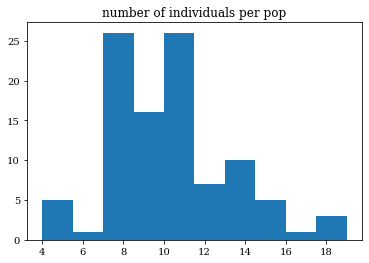

In [9]:
plt.hist([len(samps) for pop, samps in popsamps.items()])
plt.title('number of individuals per pop')

In [10]:
# add population ID to dataframe
inds['samp'] = inds.ind_index.map(samp_names)

inds['subpopID'] = inds.samp.map(samppop).astype(int)

f = f'{outerdir}/individual_data.txt'
inds.to_csv(f, sep='\t', index=False)

print(f)

inds

/work/lotterhos/brandon/continuous_space_runtime/individual_data.txt


,ind_index,x,y,phenotype1_mat,phenotype2_MTWetQ,phenotype3_MTDQ,phenotype4_PDM,phenotype5_PwarmQ,phenotype6_PWM,env1_mat,env2_MTWetQ,env3_MTDQ,env4_PDM,env5_PwarmQ,env6_PWM,samp,subpopID
0,33,0.406184,0.233272,0.737967,-0.191421,0.142992,-0.131894,-0.452497,-0.541651,0.762432,-0.162238,0.261281,-0.332078,-0.471502,-0.477821,25_33,25
1,34,0.425697,0.837158,-0.274081,-0.428332,-0.012880,0.221058,0.229296,0.066597,-0.339330,-0.407667,-0.058296,0.288030,0.198810,0.017680,85_34,85
2,44,0.671673,0.581744,-0.676326,0.086629,-0.470671,0.218813,0.260098,-0.103465,-0.567733,0.090928,-0.414353,0.234899,0.230255,-0.053511,57_44,57
3,45,0.017466,0.329922,-0.283221,-0.403942,-0.333718,-0.200554,-0.345915,-0.410001,-0.245860,-0.200759,-0.267455,-0.265260,-0.389828,-0.458979,31_45,31
4,46,0.069744,0.121221,0.057616,-0.303201,0.731600,0.195679,-0.367110,0.196296,-0.121500,-0.306379,0.702858,0.211275,-0.352307,0.212751,11_46,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8575,0.117890,0.278449,-0.070241,-0.367056,-0.061876,-0.308041,-0.468111,-0.508108,0.476928,-0.216205,0.401987,-0.377651,-0.607663,-0.374126,22_8575,22
996,8580,0.464067,0.792001,-0.050435,-0.342693,0.128758,0.107181,-0.061796,-0.081682,-0.320404,-0.411335,-0.038372,0.238443,0.145508,-0.007439,75_8580,75
997,8582,0.158645,0.682325,0.354088,0.493751,0.064744,-0.243331,-0.164916,-0.244379,0.225111,0.401138,-0.016827,-0.088830,-0.017708,-0.215783,62_8582,62
998,8585,0.894104,0.757964,-0.009027,0.424444,-0.575177,-0.514613,0.586778,0.266235,-0.028901,0.372221,-0.533756,-0.467916,0.559185,0.267799,79_8585,79


<a id='create'></a>
# create SNP files

[top](#home)

### identify marker sets

In [11]:
snps = pd.read_table(op.join(tdir, 'SNPs.txt'), delim_whitespace=True)

print(snps.shape)

snps.head()

(26371, 5)


,LG,pos_pyslim,mutname,a_freq_subset,causal
0,1,8,1-8,0.0175,False
1,1,27,1-27,0.0120,False
2,1,34,1-34,0.0370,False
3,1,81,1-81,0.0330,False
4,1,97,1-97,0.0170,False


In [12]:
# randomly sample all loci to create sets of `set_nums` loci
set_nums = [500, 5_000, 10_000, 20_000]

all_loci = snps.mutname.tolist()

loci_sets = {}
for num_loci in set_nums:
    random.shuffle(all_loci)
    
    loci_sets[num_loci] = all_loci[:num_loci]
    
    print(num_loci, len(loci_sets[num_loci]))

500 500
5000 5000
10000 10000
20000 20000


In [13]:
# look at intersection of snps across sets
for seti, setj in it.combinations(keys(loci_sets), 2):
    print(
        f'{seti = }',
        f'{setj = }',
        'intersection = %s' % len(set(loci_sets[seti]).intersection(set(loci_sets[setj])))
    )

seti = 500 setj = 5000 intersection = 98
seti = 500 setj = 10000 intersection = 172
seti = 500 setj = 20000 intersection = 382
seti = 5000 setj = 10000 intersection = 1903
seti = 5000 setj = 20000 intersection = 3816
seti = 10000 setj = 20000 intersection = 7578


In [14]:
# get the genotypes
geno = pd.read_table(op.join(tdir, 'Genotypes.txt'), delim_whitespace=True, header=None)

geno.columns = snps.mutname.tolist()

print(geno.shape)

geno.head()

(1000, 26371)


,1-8,1-27,1-34,1-81,1-97,1-153,1-154,1-206,1-287,1-304,1-346,1-364,1-368,1-389,1-495,1-508,1-525,1-585,1-689,1-837,1-846,1-869,1-921,1-933,1-1024,1-1029,1-1091,1-1113,1-1155,1-1161,1-1224,1-1259,1-1301,1-1317,1-1349,1-1357,1-1388,1-1444,1-1494,1-1499,1-1538,1-1566,1-1600,1-1635,1-1650,1-1685,1-1731,1-1793,1-1820,1-1823,...,20-997839,20-997872,20-997886,20-997954,20-998047,20-998053,20-998178,20-998299,20-998326,20-998401,20-998417,20-998418,20-998432,20-998449,20-998486,20-998561,20-998625,20-998650,20-998678,20-998720,20-998749,20-998756,20-998804,20-998842,20-998965,20-999023,20-999030,20-999103,20-999154,20-999178,20-999194,20-999218,20-999235,20-999244,20-999277,20-999288,20-999344,20-999381,20-999475,20-999525,20-999561,20-999623,20-999667,20-999683,20-999693,20-999742,20-999764,20-999823,20-999845,20-999857
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [15]:
# create snp files that have `num_loci` number of loci randomly chosen from full set
snpfiles = {}
for num_loci, loci in pbar(loci_sets.items()):
    f = f'{training_dir}/{num_loci}_snps.txt'
    
    df = geno[loci].copy()
    
    df['index'] = inds['samp']  # for compatibility with gradient_training.R script
    
    df = df[['index'] + [col for col in df.columns if col != 'index']]
    
    assert len(df.columns) == len(loci) + 1
    
    df.to_csv(f, sep='\t', index=False)
    
    snpfiles[num_loci] = f
    
print(snpfiles)

df

100%|███████████████| 4/4 [00:11<00:00,  2.77s/it]

{500: '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/500_snps.txt', 5000: '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/5000_snps.txt', 10000: '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/10000_snps.txt', 20000: '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/20000_snps.txt'}


,index,1-48481,15-727154,2-70541,11-545983,10-483820,9-420269,2-71145,7-305449,7-333602,7-330874,3-139042,4-178103,13-621737,14-673546,7-303050,12-560946,11-524287,17-826988,8-398427,16-772051,1-31273,16-780032,19-907486,3-118916,19-903228,7-327260,20-971034,13-600418,20-974256,3-112925,13-640199,6-296913,17-847598,12-560410,14-675621,12-591884,2-52173,6-293263,8-358046,17-835724,20-975914,10-471053,5-236402,12-550052,1-1820,13-638444,5-234905,12-569675,19-924184,...,13-621080,14-653806,12-598420,12-571286,11-535131,15-742189,19-943697,12-577497,19-910073,14-672041,3-126638,3-109778,7-349167,18-876418,19-944618,10-488610,13-635313,16-795436,1-20282,18-870208,18-891665,18-879448,4-158666,7-346108,14-673736,16-767241,4-168929,13-611430,17-810815,11-535357,2-59171,6-285433,13-618930,2-92481,18-873455,11-518101,20-992483,20-993728,13-647298,9-434139,14-689966,12-572609,1-28500,14-659629,13-640835,3-116108,8-368042,8-386981_2,18-889384,17-818055
0,25_33,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,85_34,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,57_44,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,31_45,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
4,11_46,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,22_8575,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
996,75_8580,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
997,62_8582,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
998,79_8585,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<a id='envdata'></a>
# create rangedata and envdata for training

[top](#home)

In [16]:
inds

,ind_index,x,y,phenotype1_mat,phenotype2_MTWetQ,phenotype3_MTDQ,phenotype4_PDM,phenotype5_PwarmQ,phenotype6_PWM,env1_mat,env2_MTWetQ,env3_MTDQ,env4_PDM,env5_PwarmQ,env6_PWM,samp,subpopID
0,33,0.406184,0.233272,0.737967,-0.191421,0.142992,-0.131894,-0.452497,-0.541651,0.762432,-0.162238,0.261281,-0.332078,-0.471502,-0.477821,25_33,25
1,34,0.425697,0.837158,-0.274081,-0.428332,-0.012880,0.221058,0.229296,0.066597,-0.339330,-0.407667,-0.058296,0.288030,0.198810,0.017680,85_34,85
2,44,0.671673,0.581744,-0.676326,0.086629,-0.470671,0.218813,0.260098,-0.103465,-0.567733,0.090928,-0.414353,0.234899,0.230255,-0.053511,57_44,57
3,45,0.017466,0.329922,-0.283221,-0.403942,-0.333718,-0.200554,-0.345915,-0.410001,-0.245860,-0.200759,-0.267455,-0.265260,-0.389828,-0.458979,31_45,31
4,46,0.069744,0.121221,0.057616,-0.303201,0.731600,0.195679,-0.367110,0.196296,-0.121500,-0.306379,0.702858,0.211275,-0.352307,0.212751,11_46,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8575,0.117890,0.278449,-0.070241,-0.367056,-0.061876,-0.308041,-0.468111,-0.508108,0.476928,-0.216205,0.401987,-0.377651,-0.607663,-0.374126,22_8575,22
996,8580,0.464067,0.792001,-0.050435,-0.342693,0.128758,0.107181,-0.061796,-0.081682,-0.320404,-0.411335,-0.038372,0.238443,0.145508,-0.007439,75_8580,75
997,8582,0.158645,0.682325,0.354088,0.493751,0.064744,-0.243331,-0.164916,-0.244379,0.225111,0.401138,-0.016827,-0.088830,-0.017708,-0.215783,62_8582,62
998,8585,0.894104,0.757964,-0.009027,0.424444,-0.575177,-0.514613,0.586778,0.266235,-0.028901,0.372221,-0.533756,-0.467916,0.559185,0.267799,79_8585,79


In [17]:
inds.columns

Index(['ind_index', 'x', 'y', 'phenotype1_mat', 'phenotype2_MTWetQ',
       'phenotype3_MTDQ', 'phenotype4_PDM', 'phenotype5_PwarmQ',
       'phenotype6_PWM', 'env1_mat', 'env2_MTWetQ', 'env3_MTDQ', 'env4_PDM',
       'env5_PwarmQ', 'env6_PWM', 'samp', 'subpopID'],
      dtype='object')

In [18]:
# create ind- and pop-level environmental data for training
envdata = {
    'ind' : inds.copy(),
    'pop' : inds.copy()
}

for level, data in envdata.items():
    data.index = data['samp'].tolist()
    
    # reduce and rename columns
    data = data[[col for col in data.columns if col.startswith('env') or col in ['x', 'y']]]
    data.columns = data.columns.str.replace('x', 'lon').str.replace('y', 'lat')    
    
    if level == 'pop':  # write pop-level envdata for each ind, else keep individual envdata
        for pop, samps in popsamps.items():
            for col in data.columns:
                if col in ['lon', 'lat']:
                    continue
                data.loc[samps, col] = data.loc[samps, col].mean()

    print(level)
    
    display(data)
    
    envdata[level] = data[[col for col in data.columns if col not in ['lon', 'lat']]].copy()

ind


,lon,lat,env1_mat,env2_MTWetQ,env3_MTDQ,env4_PDM,env5_PwarmQ,env6_PWM
25_33,0.406184,0.233272,0.762432,-0.162238,0.261281,-0.332078,-0.471502,-0.477821
85_34,0.425697,0.837158,-0.339330,-0.407667,-0.058296,0.288030,0.198810,0.017680
57_44,0.671673,0.581744,-0.567733,0.090928,-0.414353,0.234899,0.230255,-0.053511
31_45,0.017466,0.329922,-0.245860,-0.200759,-0.267455,-0.265260,-0.389828,-0.458979
11_46,0.069744,0.121221,-0.121500,-0.306379,0.702858,0.211275,-0.352307,0.212751
...,...,...,...,...,...,...,...,...
22_8575,0.117890,0.278449,0.476928,-0.216205,0.401987,-0.377651,-0.607663,-0.374126
75_8580,0.464067,0.792001,-0.320404,-0.411335,-0.038372,0.238443,0.145508,-0.007439
62_8582,0.158645,0.682325,0.225111,0.401138,-0.016827,-0.088830,-0.017708,-0.215783
79_8585,0.894104,0.757964,-0.028901,0.372221,-0.533756,-0.467916,0.559185,0.267799


/home/b.lind/anaconda3/envs/mvp_env/lib/python3.8/site-packages/pandas/core/indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
/home/b.lind/anaconda3/envs/mvp_env/lib/python3.8/site-packages/pandas/core/indexing.py:723: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value, self.name)


pop


,lon,lat,env1_mat,env2_MTWetQ,env3_MTDQ,env4_PDM,env5_PwarmQ,env6_PWM
25_33,0.406184,0.233272,0.484828,-0.218641,0.218344,-0.092163,-0.313388,-0.250675
85_34,0.425697,0.837158,-0.211409,-0.391678,0.031616,0.196956,0.101695,-0.046445
57_44,0.671673,0.581744,-0.184090,-0.258461,0.003300,0.236592,0.144834,0.139982
31_45,0.017466,0.329922,-0.206965,-0.091318,-0.251673,-0.265424,-0.371340,-0.416810
11_46,0.069744,0.121221,-0.060414,-0.298278,0.542857,0.149223,-0.375722,0.167073
...,...,...,...,...,...,...,...,...
22_8575,0.117890,0.278449,0.124594,-0.283022,0.077584,-0.197947,-0.472706,-0.285818
75_8580,0.464067,0.792001,-0.213827,-0.391341,0.028804,0.245734,0.102387,0.041150
62_8582,0.158645,0.682325,0.357723,0.449590,0.054395,-0.294251,-0.178548,-0.338785
79_8585,0.894104,0.757964,-0.088368,0.335433,-0.303577,-0.395204,0.512595,0.205361


In [19]:
# make sure env values are not duplicated
envdata['ind'].reset_index().sort_values(by='index')

,index,env1_mat,env2_MTWetQ,env3_MTDQ,env4_PDM,env5_PwarmQ,env6_PWM
10,100_119,0.066644,0.421978,-0.539388,-0.495084,0.585909,0.322847
179,100_1438,0.029492,0.410529,-0.559518,-0.467916,0.646154,0.349449
246,100_2063,0.057863,0.425002,-0.563227,-0.467916,0.600883,0.315602
370,100_3162,0.064143,0.428315,-0.553114,-0.467916,0.580220,0.309085
406,100_3427,0.098835,0.438811,-0.542021,-0.467916,0.531140,0.281561
...,...,...,...,...,...,...,...
633,9_5520,-0.370917,-0.398907,0.633050,0.411280,-0.078259,0.083914
683,9_5915,0.146712,-0.311756,0.069568,0.064908,-0.228707,-0.200100
860,9_7408,-0.041939,-0.348362,-0.182499,0.184107,-0.170008,-0.145058
904,9_7787,-0.094980,-0.348362,0.778353,0.347113,-0.141962,0.033847


In [20]:
# make sure env values are duplicated (but not index)
envdata['pop'].reset_index().sort_values(by='index')

,index,env1_mat,env2_MTWetQ,env3_MTDQ,env4_PDM,env5_PwarmQ,env6_PWM
10,100_119,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.321160
179,100_1438,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.321160
246,100_2063,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.321160
370,100_3162,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.321160
406,100_3427,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.321160
...,...,...,...,...,...,...,...
633,9_5520,-0.107908,-0.355133,0.402415,0.268017,-0.147895,-0.046969
683,9_5915,-0.107908,-0.355133,0.402415,0.268017,-0.147895,-0.046969
860,9_7408,-0.107908,-0.355133,0.402415,0.268017,-0.147895,-0.046969
904,9_7787,-0.107908,-0.355133,0.402415,0.268017,-0.147895,-0.046969


In [21]:
# save envdata and rangedata
# rangefiles are just envdata without the index (since inds or pops aren't needed to be indexed)
envfiles = {}
rangefiles = {}
for level, data in envdata.items():
    f = f'{training_dir}/{level}_envdata.txt'
    
    data.to_csv(f, sep='\t', index=True, header=True)
    
    envfiles[level] = f
    
    rangef = f'{training_dir}/{level}_rangedata.txt'
    
    data.to_csv(rangef, sep='\t', index=False, header=True)
    
    rangefiles[level] = rangef
    
envfiles

{'ind': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/ind_envdata.txt',
 'pop': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/pop_envdata.txt'}

In [22]:
rangefiles

{'ind': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/ind_rangedata.txt',
 'pop': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/pop_rangedata.txt'}

<a id='resources'></a>
# figure out mem and run time using previous genotype data

[top](#home)

In [23]:
f = '/work/lotterhos/brandon/runtime/figures/03_Q3_computational_requirements/training_seff_df.txt'

training_df = pd.read_table(f)

training_df

,slurm_job_id,nodes,cpus,core_walltime_hrs,cpu_efficiency,cpu_usage_hrs,memory_used_MB,memory_efficiency,memory_requested_MB,state,walltime_hrs,out,job,sh,source,rep,num_loci,seed,final_LA,glevel,plevel,pleio,slevel,landscape,popsize,migration,landscape-slevel,final_la_bin,model
0,40437730,1,1,0.124167,98.66%,0.122500,7823.36,15.64%,50001.92,State: COMPLETED (exit code 0),0.124167,/work/lotterhos/brandon/ind_runtimes/run_20220...,1231109_GF_training_ind_all,/work/lotterhos/brandon/ind_runtimes/run_20220...,ind,run_20220919_0-225,500,1231109,0.501332,highly-polygenic,2-trait,no pleiotropy,equal-S,Est-Clines,N-cline-center-to-edge,m-constant,Est-Clines_equal-S,0.42 < LA ≤ 0.58,geno-model
1,40437731,1,1,0.118056,98.35%,0.116111,6656.00,13.30%,50001.92,State: COMPLETED (exit code 0),0.118056,/work/lotterhos/brandon/ind_runtimes/run_20220...,1231110_GF_training_ind_all,/work/lotterhos/brandon/ind_runtimes/run_20220...,ind,run_20220919_0-225,500,1231110,0.493447,highly-polygenic,2-trait,no pleiotropy,equal-S,Est-Clines,N-cline-N-to-S,m-constant,Est-Clines_equal-S,0.42 < LA ≤ 0.58,geno-model
2,40437732,1,1,0.110556,99.25%,0.109722,6594.56,13.20%,50001.92,State: COMPLETED (exit code 0),0.110556,/work/lotterhos/brandon/ind_runtimes/run_20220...,1231111_GF_training_ind_all,/work/lotterhos/brandon/ind_runtimes/run_20220...,ind,run_20220919_0-225,500,1231111,0.501673,highly-polygenic,2-trait,no pleiotropy,equal-S,Est-Clines,N-equal,m-breaks,Est-Clines_equal-S,0.42 < LA ≤ 0.58,geno-model
3,40437733,1,1,0.117222,97.87%,0.114722,7116.80,14.24%,50001.92,State: COMPLETED (exit code 0),0.117222,/work/lotterhos/brandon/ind_runtimes/run_20220...,1231112_GF_training_ind_all,/work/lotterhos/brandon/ind_runtimes/run_20220...,ind,run_20220919_0-225,500,1231112,0.497658,highly-polygenic,2-trait,no pleiotropy,equal-S,Est-Clines,N-equal,m-constant,Est-Clines_equal-S,0.42 < LA ≤ 0.58,geno-model
4,40437734,1,1,0.121667,97.26%,0.118333,8724.48,17.46%,50001.92,State: COMPLETED (exit code 0),0.121667,/work/lotterhos/brandon/ind_runtimes/run_20220...,1231113_GF_training_ind_all,/work/lotterhos/brandon/ind_runtimes/run_20220...,ind,run_20220919_0-225,500,1231113,0.512199,highly-polygenic,2-trait,no pleiotropy,equal-S,Est-Clines,N-variable,m-variable,Est-Clines_equal-S,0.42 < LA ≤ 0.58,geno-model
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4315,40811752,1,1,1.710833,99.95%,1.710000,53790.72,29.88%,179998.72,State: COMPLETED (exit code 0),1.710833,/work/lotterhos/brandon/pooled_runtimes/run_20...,1231764_GF_training_pooled_all,/work/lotterhos/brandon/pooled_runtimes/run_20...,pooled,run_20220919_450-675,20000,1231764,0.397212,oligogenic,2-trait,pleiotropy,unequal-S,SS-Mtn,N-cline-center-to-edge,m-constant,SS-Mtn_unequal-S,0.27 < LA ≤ 0.42,af-model
4316,40811753,1,1,1.738889,99.92%,1.737500,59238.40,32.91%,179998.72,State: COMPLETED (exit code 0),1.738889,/work/lotterhos/brandon/pooled_runtimes/run_20...,1231765_GF_training_pooled_all,/work/lotterhos/brandon/pooled_runtimes/run_20...,pooled,run_20220919_450-675,20000,1231765,0.389291,oligogenic,2-trait,pleiotropy,unequal-S,SS-Mtn,N-cline-N-to-S,m-constant,SS-Mtn_unequal-S,0.27 < LA ≤ 0.42,af-model
4317,40811754,1,1,1.940000,99.94%,1.938889,80916.48,44.95%,179998.72,State: COMPLETED (exit code 0),1.940000,/work/lotterhos/brandon/pooled_runtimes/run_20...,1231766_GF_training_pooled_all,/work/lotterhos/brandon/pooled_runtimes/run_20...,pooled,run_20220919_450-675,20000,1231766,0.415404,oligogenic,2-trait,pleiotropy,unequal-S,SS-Mtn,N-equal,m-breaks,SS-Mtn_unequal-S,0.27 < LA ≤ 0.42,af-model
4318,40811755,1,1,1.143889,99.95%,1.143333,59463.68,33.03%,179998.72,State: COMPLETED (exit code 0),1.143889,/work/lotterhos/brandon/pooled_runtimes/run_20...,1231767_GF_training_pooled_all,/work/lotterhos/brandon/pooled_runtimes/run_20...,pooled,run_20220919_450-675,20000,1231767,0.403683,oligogenic,2-trait,pleiotropy,unequal-S,SS-Mtn,N-equal,m-constant,

In [24]:
memreq = {}
for num_loci in training_df.num_loci.unique():
    mem = training_df[training_df.num_loci == num_loci]['memory_used_MB'].max()
    time_ = training_df[training_df.num_loci == num_loci]['walltime_hrs'].max()
    
    print(num_loci, mem, int(round(mem, -3)), formatclock(time_))
    
    memreq[num_loci] = int(round(mem, -3))

# manually create timereq from printed clocks (with rounding up)
timereq = {
    500 : '0-04:00:00',
    5000 : '0-12:00:00',
    10000 : '1-00:00:00',
    20000 : '1-12:00:00'
}

partitions = {
    500 : 'short',
    5000 : 'short',
    10000 : 'short',
    20000 : 'long'
}

memreq

500 9523.2 10000 0-00:10:52
5000 100638.72 101000 0-05:32:28
10000 197898.24 198000 0-18:22:29
20000 361420.8 361000 1-00:00:29


{500: 10000, 5000: 101000, 10000: 198000, 20000: 361000}

<a id='train'></a>
# create training shfiles

[top](#home)

In [25]:
rscript_exe = '/home/b.lind/anaconda3/envs/r35/lib/R/bin/Rscript'
training_script = '/home/b.lind/code/MVP-offsets/01_src/MVP_gf_training_script.R'

In [26]:
envfiles

{'ind': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/ind_envdata.txt',
 'pop': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/pop_envdata.txt'}

In [27]:
rangefiles

{'ind': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/ind_rangedata.txt',
 'pop': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/pop_rangedata.txt'}

In [28]:
training_dir

'/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files'

In [29]:
rt.resdir

'/work/lotterhos/brandon/runtime'

In [30]:
training_jobs = defaultdict(dict)
shfiles = defaultdict(dict)
for num_loci, snpfile in snpfiles.items():
    for level in keys(envdata):
        job = f'tutorial_GF_training_{num_loci}_{level}'
        training_jobs[num_loci][level] = job

        mem = memreq[num_loci]

        time_ = timereq[num_loci]

        partition = partitions[num_loci]

        shtext = f'''#!/bin/bash
#SBATCH --job-name={job}
#SBATCH --time={time_}
#SBATCH --mem={mem}M
#SBATCH --partition={partition}
#SBATCH --output={job}_%j.out

source $HOME/.bashrc  # assumed that conda init is within .bashrc
conda deactivate
conda activate r35

cd {training_dir}

{rscript_exe} \\
{training_script} \\
{snpfile} \\
{envfiles[level]} \\
{rangefiles[level]} \\
{job} \\
{outdir}

'''

        shfile = f'{shdir}/{job}.sh'
        with open(shfile, 'w') as o:
            o.write(shtext)

        shfiles[num_loci][level] = shfile

shfiles

defaultdict(dict,
            {500: {'ind': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_shfiles/tutorial_GF_training_500_ind.sh',
              'pop': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_shfiles/tutorial_GF_training_500_pop.sh'},
             5000: {'ind': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_shfiles/tutorial_GF_training_5000_ind.sh',
              'pop': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_shfiles/tutorial_GF_training_5000_pop.sh'},
             10000: {'ind': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_shfiles/tutorial_GF_training_10000_ind.sh',
              'pop': '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_shfiles/tutorial_GF_training_10000_pop.sh'},
             20000: {'ind': '/work/lotterhos/brandon/continuous_spa

In [31]:
print(shtext)

#!/bin/bash
#SBATCH --job-name=tutorial_GF_training_20000_pop
#SBATCH --time=1-12:00:00
#SBATCH --mem=361000M
#SBATCH --partition=long
#SBATCH --output=tutorial_GF_training_20000_pop_%j.out

source $HOME/.bashrc  # assumed that conda init is within .bashrc
conda deactivate
conda activate r35

cd /work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files

/home/b.lind/anaconda3/envs/r35/lib/R/bin/Rscript \
/home/b.lind/code/MVP-offsets/01_src/MVP_gf_training_script.R \
/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/20000_snps.txt \
/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/pop_envdata.txt \
/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_files/pop_rangedata.txt \
tutorial_GF_training_20000_pop \
/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/training/training_outfiles




In [32]:
# submit the jobs to the queue
pids = defaultdict(dict)
for (num_loci, level), shfile in unwrap_dictionary(shfiles):
    pids[num_loci][level] = sbatch(shfile, progress_bar=False)[0]
    
pids

defaultdict(dict,
            {500: {'ind': '45348663', 'pop': '45348664'},
             5000: {'ind': '45348665', 'pop': '45348666'},
             10000: {'ind': '45348667', 'pop': '45348668'},
             20000: {'ind': '45348669', 'pop': '45348670'}})

### (end of training section)

<a id='predict'></a>
# get common garden data for predicting offset

use the average climate of each population as the common garden

[top](#home)

In [33]:
df.columns

Index(['index', '1-48481', '15-727154', '2-70541', '11-545983', '10-483820',
       '9-420269', '2-71145', '7-305449', '7-333602',
       ...
       '14-689966', '12-572609', '1-28500', '14-659629', '13-640835',
       '3-116108', '8-368042', '8-386981_2', '18-889384', '17-818055'],
      dtype='object', length=20001)

In [34]:
df = envdata['pop'].copy()

df['subpopID'] = df.index.map(samppop)

df.groupby('subpopID').apply(np.mean)

print(ColorText('this is just a display, scroll to see `garden_data`').fail().bold())
display(df.sort_values(by='subpopID'))  # show means were calculated

garden_data = pd.DataFrame(columns = df.columns)
for pop in df.subpopID.unique():
    garden_data.loc[pop] = df.loc[df.subpopID == pop, garden_data.columns].iloc[0]

garden_data.index = garden_data.subpopID.astype(int).tolist()
garden_data.sort_values(by='subpopID', inplace=True)
garden_data.pop('subpopID')


garden_data

this is just a display, scroll to see `garden_data`


,env1_mat,env2_MTWetQ,env3_MTDQ,env4_PDM,env5_PwarmQ,env6_PWM,subpopID
1_271,0.186225,-0.226935,0.861531,0.221974,-0.363974,0.761569,1
1_6220,0.186225,-0.226935,0.861531,0.221974,-0.363974,0.761569,1
1_8172,0.186225,-0.226935,0.861531,0.221974,-0.363974,0.761569,1
1_7833,0.186225,-0.226935,0.861531,0.221974,-0.363974,0.761569,1
1_4616,0.186225,-0.226935,0.861531,0.221974,-0.363974,0.761569,1
...,...,...,...,...,...,...,...
100_1438,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.321160,100
100_3575,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.321160,100
100_3427,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.321160,100
100_4364,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.321160,100


,env1_mat,env2_MTWetQ,env3_MTDQ,env4_PDM,env5_PwarmQ,env6_PWM
1,0.186225,-0.226935,0.861531,0.221974,-0.363974,0.761569
2,0.070353,-0.265649,0.799727,0.169512,-0.417965,0.315295
3,0.264633,-0.248372,0.375248,-0.172690,-0.586408,-0.320803
4,0.371616,0.167485,0.063118,-0.465978,-0.656053,-0.625240
5,0.244613,0.117437,-0.010939,-0.291486,-0.528748,-0.537376
...,...,...,...,...,...,...
96,-0.288220,0.261489,-0.317123,-0.018548,0.228030,-0.045559
97,-0.116570,0.323553,-0.231351,-0.269762,0.344912,0.059459
98,0.093915,0.400397,-0.150975,-0.408936,0.588880,0.274592
99,0.034177,0.399089,-0.440848,-0.464035,0.673533,0.360201


In [35]:
garden_data

,env1_mat,env2_MTWetQ,env3_MTDQ,env4_PDM,env5_PwarmQ,env6_PWM
1,0.186225,-0.226935,0.861531,0.221974,-0.363974,0.761569
2,0.070353,-0.265649,0.799727,0.169512,-0.417965,0.315295
3,0.264633,-0.248372,0.375248,-0.172690,-0.586408,-0.320803
4,0.371616,0.167485,0.063118,-0.465978,-0.656053,-0.625240
5,0.244613,0.117437,-0.010939,-0.291486,-0.528748,-0.537376
...,...,...,...,...,...,...
96,-0.288220,0.261489,-0.317123,-0.018548,0.228030,-0.045559
97,-0.116570,0.323553,-0.231351,-0.269762,0.344912,0.059459
98,0.093915,0.400397,-0.150975,-0.408936,0.588880,0.274592
99,0.034177,0.399089,-0.440848,-0.464035,0.673533,0.360201


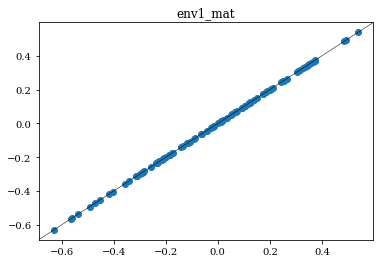

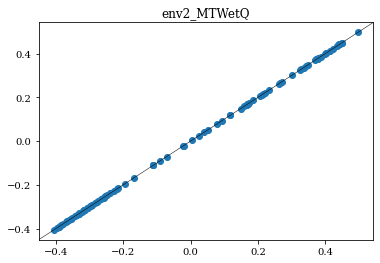

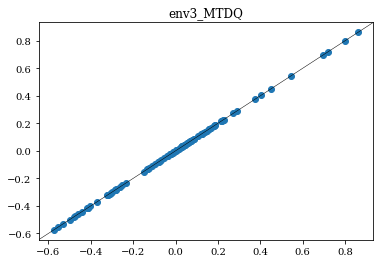

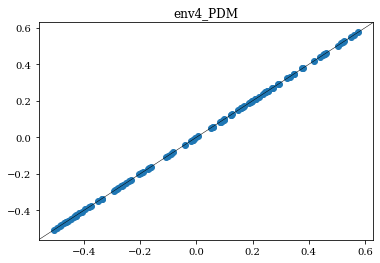

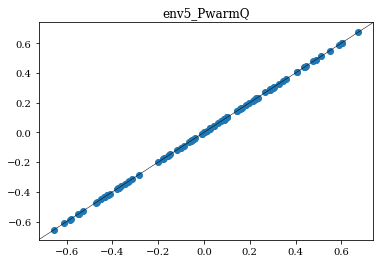

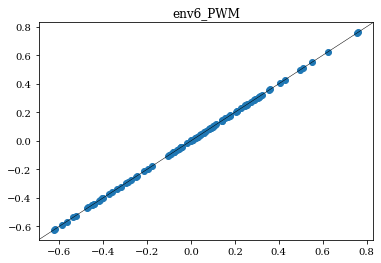

In [36]:
# make sure I did this the same way as before (as in Lind & lotterhos 2024 Mol Ecol Res)

popenvdata = pd.read_table(
    '/home/b.lind/offsets/run_20220919_tutorial/gradient_forests/training/training_files/tutorial_envfile_GFready_pooled.txt',
    index_col=0
)

for col in popenvdata.columns:
    plt.scatter(popenvdata[col], garden_data[col])
    ax = plt.gca()
    mf.draw_xy(ax)
    ax.set_title(col)
    plt.show()

In [37]:
# example of replicating rows
garden_data.loc[[1, 1, 1]].reset_index(drop=True)

,env1_mat,env2_MTWetQ,env3_MTDQ,env4_PDM,env5_PwarmQ,env6_PWM
0,0.186225,-0.226935,0.861531,0.221974,-0.363974,0.761569
1,0.186225,-0.226935,0.861531,0.221974,-0.363974,0.761569
2,0.186225,-0.226935,0.861531,0.221974,-0.363974,0.761569


In [38]:
inds.shape

(1000, 17)

In [39]:
garden_dir

'/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/fitting/garden_files'

In [40]:
list(range(1, 10+1))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [41]:
assert all(envdata['ind'].index == envdata['pop'].index)

In [42]:
# create garden files, repeating the garden's climate for each individual (rows)
garden_files = []
for garden in pbar(garden_data.index):

    df = garden_data.loc[[garden for i in range(nrow(inds))]]
    
    df.index = envdata['ind'].index.tolist()  # for compatibility with MVP_gf_fitting_script.R
    
    f = f'{garden_dir}/tutorial_GF_gardenfile_{garden}.txt'
    df.to_csv(f, sep='\t', index=True, header=True)
    
    garden_files.append(f)

time.sleep(0.5)
print(len(garden_files))
    
df

100%|███████████████| 100/100 [00:02<00:00, 41.21it/s]


100


,env1_mat,env2_MTWetQ,env3_MTDQ,env4_PDM,env5_PwarmQ,env6_PWM
25_33,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.32116
85_34,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.32116
57_44,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.32116
31_45,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.32116
11_46,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.32116
...,...,...,...,...,...,...
22_8575,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.32116
75_8580,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.32116
62_8582,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.32116
79_8585,0.055334,0.422488,-0.553991,-0.472096,0.604139,0.32116


In [43]:
f

'/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/fitting/garden_files/tutorial_GF_gardenfile_100.txt'

<a id='fitsh'></a>
# create shfiles for offset prediction

I forgot to specify the garden ID so have to restart and submit from here

[top](#home)

In [1]:
from pythonimports import *
import myfigs as mf

import MVP_03_validate_gradient_forests as mvp03
import MVP_06_validate_RONA as mvp06
import MVP_summary_functions as mvp
import runtime_API as rt

import seaborn as sns
import itertools as it

outerdir = '/work/lotterhos/brandon/continuous_space_runtime'

# continuous space sims directory
tdir = '/home/b.lind/offsets/run_20220919_tutorial/tutorial'

# where to save GF files
training_dir = f'{outerdir}/gradient_forests/training/training_files'
outdir = f'{outerdir}/gradient_forests/training/training_outfiles'
shdir = f'{outerdir}/gradient_forests/training/training_shfiles'

fitting_dir = f'{outerdir}/gradient_forests/fitting'
fitting_outdir = f'{fitting_dir}/fitting_outfiles'
fitting_shdir = f'{fitting_dir}/fitting_shfiles'
garden_dir = f'{fitting_dir}/garden_files'
cmddir = f'{fitting_dir}/command_files'

t0 = dt.now()  # notebook timer

rt.latest_commit()
session_info.show()

#########################################################
Today:	December 04, 2024 - 13:31:06 EST
python version: 3.8.5
conda env: mvp_env

Current commit of pythonimports:
commit 6a767410e7b569adbf9df526de108f22ef50aad8  
Author: Brandon Lind <lind.brandon.m@gmail.com>  
Date:   Wed Mar 6 13:42:13 2024 -0700

Current commit of MVP_offsets:
commit 5ce82f4d655645237a0f4026fa32e220226dc373  
Author: Brandon Lind <lind.brandon.m@gmail.com>  
Date:   Thu May 16 13:02:58 2024 -0400

Current commit of MVP_runtime:
commit a98ef38f88b81d808c334e87d0c6392e142941da  
Merge: 50cf2c9 cc54cc3  
Author: Brandon Lind <lind.brandon.m@gmail.com>
#########################################################



In [2]:
# from above
pids = defaultdict(dict,
                   {500: {'ind': '45348663', 'pop': '45348664'},
                    5000: {'ind': '45348665', 'pop': '45348666'},
                    10000: {'ind': '45348667', 'pop': '45348668'},
                    20000: {'ind': '45348669', 'pop': '45348670'}})

In [3]:
# get garden files created above
garden_files = fs(garden_dir, endswith='.txt')

len(garden_files)

100

In [4]:
# repopulate training_jobs
training_jobs = defaultdict(dict)
for (num_loci, level), pid in unwrap_dictionary(pids):
    job = f'tutorial_GF_training_{num_loci}_{level}'
    training_jobs[num_loci][level] = job
    
training_jobs

defaultdict(dict,
            {500: {'ind': 'tutorial_GF_training_500_ind',
              'pop': 'tutorial_GF_training_500_pop'},
             5000: {'ind': 'tutorial_GF_training_5000_ind',
              'pop': 'tutorial_GF_training_5000_pop'},
             10000: {'ind': 'tutorial_GF_training_10000_ind',
              'pop': 'tutorial_GF_training_10000_pop'},
             20000: {'ind': 'tutorial_GF_training_20000_ind',
              'pop': 'tutorial_GF_training_20000_pop'}})

In [5]:
# determine runtimes

f = '/work/lotterhos/brandon/runtime/figures/03_Q3_computational_requirements/fitting_seff_df.txt'

fitting_df = pd.read_table(f)

for num_loci in fitting_df.num_loci.unique():
    df = fitting_df[fitting_df.num_loci == num_loci]
    
    print(num_loci, formatclock(df.cpu_usage_hrs.max()), df.memory_used_MB.max())

# manually fill in based on print outs
fitmems = {
    500 : 14000,
    5000 : 110000,
    10000 : 220000,
    20000 : 431000,
}

fittimes = {
    500 : '0-04:00:00',
    5000 : '0-12:00:00',
    10000 : '0-16:00:00',
    20000 : '1-00:00:00',
}

500 0-00:23:59 13363.2
5000 0-03:49:22 108503.04
10000 0-08:22:42 217661.44
20000 0-14:50:18 430848.0


In [6]:
rscript_exe = '/home/b.lind/anaconda3/envs/r35/lib/R/bin/Rscript'

threads = 7

fitting_script = '/home/b.lind/code/MVP-offsets/01_src/MVP_gf_fitting_script.R'

fitting_shfiles = []
for (num_loci, level), pid in unwrap_dictionary(pids):

    training_basename = training_jobs[num_loci][level] # f'tutorial_GF_training_{num_loci}_pop' 
    basename = f'tutorial_GF_fitting_{num_loci}_{level}'

    mem = fitmems[num_loci]

    time_ = fittimes[num_loci]

    # create commands for each garden climate, 
    cmds = []
    for gardenfile in garden_files:
        garden = op.basename(gardenfile).split('.')[0].split("_")[-1]
        cmds.append(
            ' '.join(
                [
                    rscript_exe,
                    fitting_script,

                    f'{outdir}/{training_basename}_gradient_forest_training.RDS',
                    gardenfile,
                    f'{outdir}/{training_basename}_gradient_forest_predOut.RDS',
                    f'{training_basename}_{garden}',
                    fitting_outdir

    #                 gfOut_trainingfile <- args[1]
    #                 garden_file        <- args[2]
    #                 predfile           <- args[3]
    #                 basename           <- args[4]
    #                 save_dir           <- args[5]
                ]
            )
        )

    cmdfile = f'{cmddir}/cmds_{num_loci}_{level}.txt'
    with open(cmdfile, 'w') as o:
        o.write('\n'.join(cmds))


    text = f'''#!/bin/bash
#SBATCH --job-name={basename}
#SBATCH --time={time_}
#SBATCH --ntasks=1
#SBATCH --mem={mem}M
#SBATCH --output={basename}_%j.out
#SBATCH --partition='short'
#SBATCH --nodes=1
#SBATCH --cpus-per-task={threads}

source $HOME/.bashrc

conda activate r35

module load parallel

cat {cmdfile} | parallel -j {threads} --progress

'''
    shfile = f'{fitting_shdir}/{basename}.sh'
    with open(shfile, 'w') as o:
        o.write(text)

    fitting_shfiles.append(shfile)

In [7]:
fitting_shfiles

['/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/fitting/fitting_shfiles/tutorial_GF_fitting_500_ind.sh',
 '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/fitting/fitting_shfiles/tutorial_GF_fitting_500_pop.sh',
 '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/fitting/fitting_shfiles/tutorial_GF_fitting_5000_ind.sh',
 '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/fitting/fitting_shfiles/tutorial_GF_fitting_5000_pop.sh',
 '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/fitting/fitting_shfiles/tutorial_GF_fitting_10000_ind.sh',
 '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/fitting/fitting_shfiles/tutorial_GF_fitting_10000_pop.sh',
 '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/fitting/fitting_shfiles/tutorial_GF_fitting_20000_ind.sh',
 '/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/fitting/fitting_shfiles/tutorial_GF_fitting_20000

In [8]:
fitpids = sbatch(fitting_shfiles)

sbatching: 100%|███████████████| 8/8 [00:01<00:00,  6.51it/s]


In [9]:
create_watcherfile(fitpids, fitting_shdir, 'fitting_watcher', email='lind.brandon.m@gmail.com', begin_alert=True)

['45360368']


'/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/fitting/fitting_shfiles/fitting_watcher.sh'

In [10]:
fitpids

['45360360',
 '45360361',
 '45360362',
 '45360363',
 '45360364',
 '45360365',
 '45360366',
 '45360367']

In [11]:
formatclock(dt.now() - t0)

'0-00:00:02'

# from the runs that made mistakes

executing seff commands: 100%|███████████████| 9/9 [00:02<00:00,  3.25it/s]


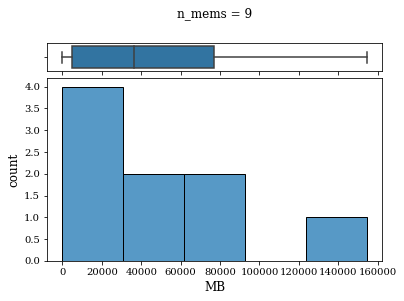

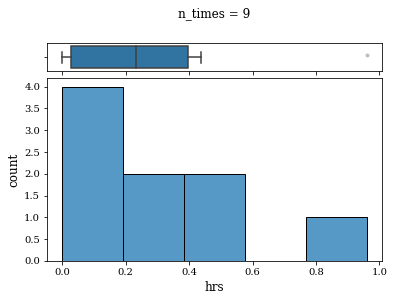

In [12]:
seffs = Seffs(fs('/work/lotterhos/brandon/continuous_space_runtime/gradient_forests/fitting/fitting_shfiles', endswith='.out'))

seffs.plot_mems()

seffs.plot_times()

In [16]:
# update the correct runs to reduce memory req
Squeue(states='PD', exclude='watcher').update(minmemorynode=150000)

update: 100%|███████████████| 2/2 [00:00<00:00, 13.31it/s]
